# Label extraction from radiology reports

Select the **Python (RSNA Knee)** kernel in the top-right before running cells.

Reports exist in train only. The MRI model never sees them at test time. This notebook builds a **report → 12 binary labels** mapper so the ~4,349 unlabeled studies can become silver training data.

**v0 plan (do in order):**
1. Harness: `predict` + `evaluate` on gold (this notebook inits that).
2. Keyword rules, starting with Effusion / Baker's, then ACL (watch negation).
3. Error analysis: print false positives / false negatives for the worst label.
4. Fix one failure class, re-score. Only then consider a heavier model.

Your work starts at the keyword dict inside `predict`. Run the all-zero baseline first so you know the scoreboard works (recall should be 0).

In [28]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    multilabel_confusion_matrix,
    precision_recall_fscore_support,
)

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 20)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("Working directory:", Path.cwd())

Python: 3.11.5
pandas: 3.0.5
Working directory: /Users/paramtully/IdeaProjects/TechnicalProjects/RSNA-Knee-Abnormality-Detection


In [29]:
DATA_DIR = Path(".")

LABELS = [
    "ACL", "MCL", "Medial Meniscus", "Lateral Meniscus",
    "Medial OA", "Lateral OA", "PF OA", "Effusion",
    "Synovitis", "Baker's", "Contusion", "Fracture",
]

train = pd.read_csv(DATA_DIR / "train.csv")
gold = train.loc[train[LABELS].notna().all(axis=1)].copy()
unlabeled = train.loc[train[LABELS].isna().all(axis=1)].copy()

print("train:", train.shape)
print("gold:", gold.shape)
print("unlabeled:", unlabeled.shape)
assert gold.shape[0] == 58, gold.shape[0]
assert unlabeled.shape[0] == 4407 - 58, unlabeled.shape[0]

train: (4407, 14)
gold: (58, 14)
unlabeled: (4349, 14)


In [ ]:
# define the functions used to evaluate the performance of the label extraction

    # Score a report→label mapper against the 58 gold studies.
    # REQUIRES: pred has all LABELS columns and the same number of rows as gold, in the same order
    # MODIFIES: nothing
    # EFFECTS: displays a per-label scoreboard and an fp-vs-fn bar chart; returns the scoreboard
def evaluate(pred: pd.DataFrame) -> pd.DataFrame:
    y = gold[LABELS].astype(int)
    p = pred[LABELS].astype(int)
    p.index = y.index

    prec, rec, f1, support = precision_recall_fscore_support(
        y, p, average=None, zero_division=0
    )
    # per label: [[tn, fp], [fn, tp]]
    cms = multilabel_confusion_matrix(y, p)
    scores = pd.DataFrame(
        {
            "support": support.astype(int),
            "tp": cms[:, 1, 1],
            "fp": cms[:, 0, 1],
            "fn": cms[:, 1, 0],
            "precision": prec,
            "recall": rec,
            "f1": f1,
        },
        index=LABELS,
    )
    display(scores)
    print(f"prediction accuracy (all 12 correct): {accuracy_score(y, p):.4f}")
    print(f"macro f1: {f1_score(y, p, average='macro', zero_division=0):.4f}")

    err_counts = scores.reset_index(names="label")[["label", "fp", "fn"]]
    err_long = err_counts.melt(id_vars="label", var_name="error", value_name="count")
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(
        data=err_long,
        x="label",
        y="count",
        hue="error",
        palette={"fp": "#d62728", "fn": "#1f77b4"},
        ax=ax,
    )
    ax.set_title("false positives vs false negatives (higher = worse)")
    ax.set_xlabel("label")
    ax.set_ylabel("count among 58 gold studies")
    plt.xticks(rotation=45, ha="right")
    fig.tight_layout()
    plt.show()
    return scores

def get_pred(mapper):
    return pd.DataFrame(gold["Report"].map(mapper).tolist(), index=gold.index)


,support,tp,fp,fn,precision,recall,f1
ACL,24,7,14,17,0.333333,0.291667,0.311111
MCL,9,3,14,6,0.176471,0.333333,0.230769
Medial Meniscus,26,12,10,14,0.545455,0.461538,0.500000
Lateral Meniscus,23,11,10,12,0.523810,0.478261,0.500000
Medial OA,15,0,0,15,0.000000,0.000000,0.000000
Lateral OA,11,0,0,11,0.000000,0.000000,0.000000
PF OA,21,0,0,21,0.000000,0.000000,0.000000
Effusion,35,15,13,20,0.535714,0.428571,0.476190
Synovitis,27,6,3,21,0.666667,0.222222,0.333333
Baker's,12,2,6,10,0.250000,0.166667,0.200000


prediction accuracy (all 12 correct): 0.0000
macro f1: 0.2907


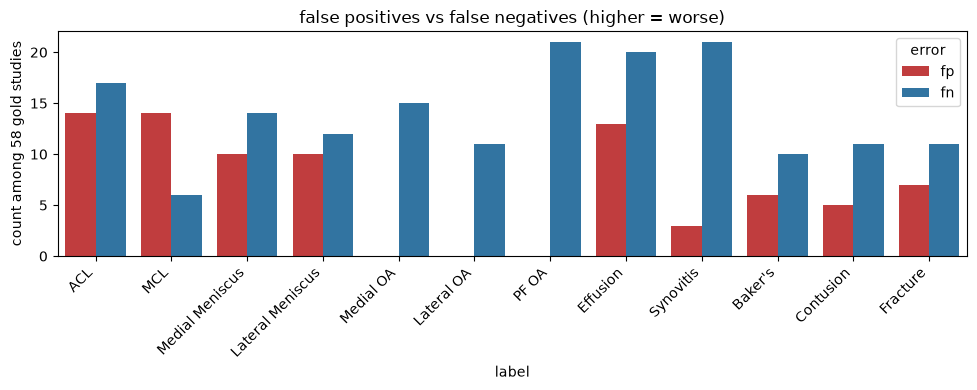

In [ ]:
# try simple label search 
def predict_simple_extract(report: str) -> dict:
    text = "" if report is None else str(report).lower()
    return {label: int(label.lower() in text) for label in LABELS}

pred = get_pred(predict_simple_extract)
scores = evaluate(pred)


Findings: 
    - there are cases where the label (diagnosed) was not found in the report
        -> possible for multiple reasons: annotated vs fully spelled out, different language
    - some false positives could be from negations being recorded as diagnoses